## Set up AnnData object with integration winner, and plot UMAP

In [1]:
# Path and system utilities
import os                    # Operating system interface
import sys                   # System-specific parameters and functions
from pyhere import here      # Reproducible project paths

# Single-cell data handling
import anndata               # Core data structure for single-cell data
import scanpy as sc          # Analysis and visualization of single-cell data

# Data visualization
import seaborn as sns        # Statistical data visualization
import matplotlib.pyplot as plt  # Plotting interface
import matplotlib            # Base matplotlib functionality
from matplotlib.backends.backend_pdf import PdfPages  # Save plots to multi-page PDFs

# Miscellaneous utilities
import warnings              # Suppress or manage warnings

# Custom modules and functions
sys.path.append(str(here('scripts/misc')))  # Add custom script path to system
import my_anndata as ma                    # Custom AnnData utilities


Parameters

In [2]:
base_dir = str(here('data/integrate/second_pass/'))
plot_dir = os.path.join(base_dir, 'plot') 
objects_dir = os.path.join(base_dir, 'objects') 

In [3]:
# Plotting
plt.style.use('default') 

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
 # 
SMALL_SIZE = 4
MEDIUM_SIZE = 6
BIGGER_SIZE = 8
 
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=SMALL_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

sc.set_figure_params(figsize=(2, 2), frameon=False, dpi_save= 300)

sc.settings.figdir = plot_dir
%config InlineBackend.print_figure_kwargs={'facecolor': 'w'}
%config InlineBackend.figure_format='retina'

Import data

In [4]:
adata_full =sc.read_h5ad(os.path.join(objects_dir, 'AB_adata_full_with_latent.h5ad'))

Plot faceted UMAP

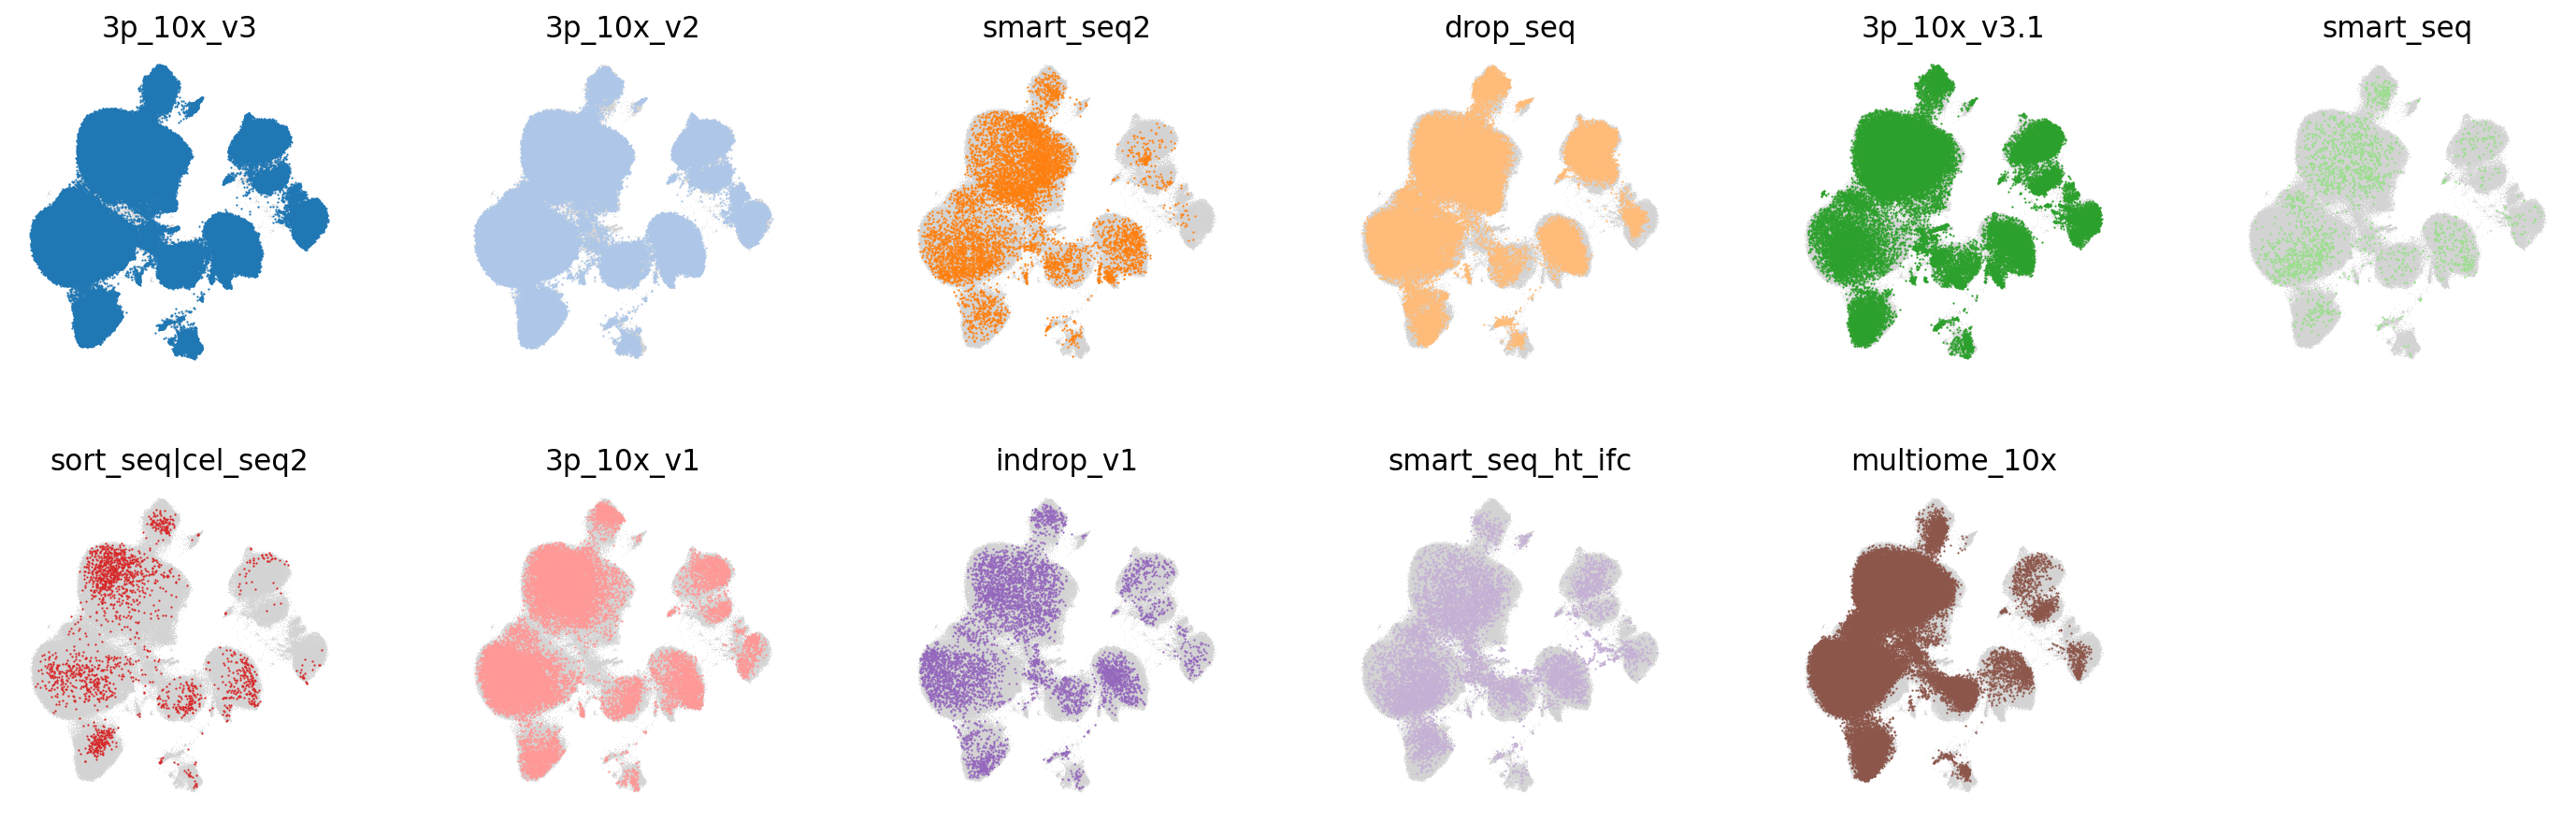

In [8]:
fig, colors = ma.umap_facet(ad = adata_full, 
                 variable = 'library_prep', 
                 ncols = 6, pt_size= 5,
                 exclude = False, exclude_key = "10x",
                 umap_key = "X_latent_2_umap")